In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime

In [7]:
# Leer y parsear el archivo log
def cargar_datos(path):
    with open(path, encoding='utf-8') as f:
        lineas = f.readlines()

    registros = []
    for linea in lineas:
        match = re.match(r"- (\d{4}-\d{2}-\d{2} \d{2}:\d{2}) \| ([\d.]+) min \| (.+)", linea.strip())
        if match:
            fecha = datetime.strptime(match[1], '%Y-%m-%d %H:%M')
            minutos = float(match[2])
            estado = match[3]
            registros.append((fecha, minutos, estado))

    df = pd.DataFrame(registros, columns=["fecha", "minutos", "estado"])
    df["hora"] = df["fecha"].dt.hour
    df["dia_semana"] = df["fecha"].dt.day_name()
    return df

/var/folders/p4/zf8v2ws90zq6_fhb5dmq0d1r0000gn/T/ipykernel_3527/284308251.py:11: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/base/Library/Mobile Documents/com~apple~CloudDocs/VSC/trafico/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


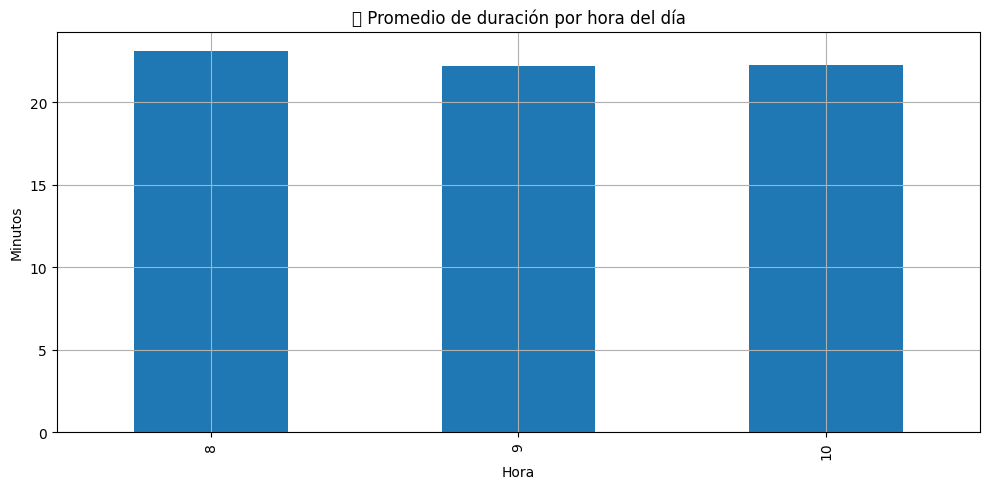

In [8]:
# Cargar datos
df = cargar_datos("trafico_log.md")

# Gráfico 1: duración por hora del día
plt.figure(figsize=(10, 5))
df.groupby("hora")["minutos"].mean().plot(kind="bar")
plt.title("⏰ Promedio de duración por hora del día")
plt.ylabel("Minutos")
plt.xlabel("Hora")
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/p4/zf8v2ws90zq6_fhb5dmq0d1r0000gn/T/ipykernel_3527/1613691945.py:9: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/base/Library/Mobile Documents/com~apple~CloudDocs/VSC/trafico/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


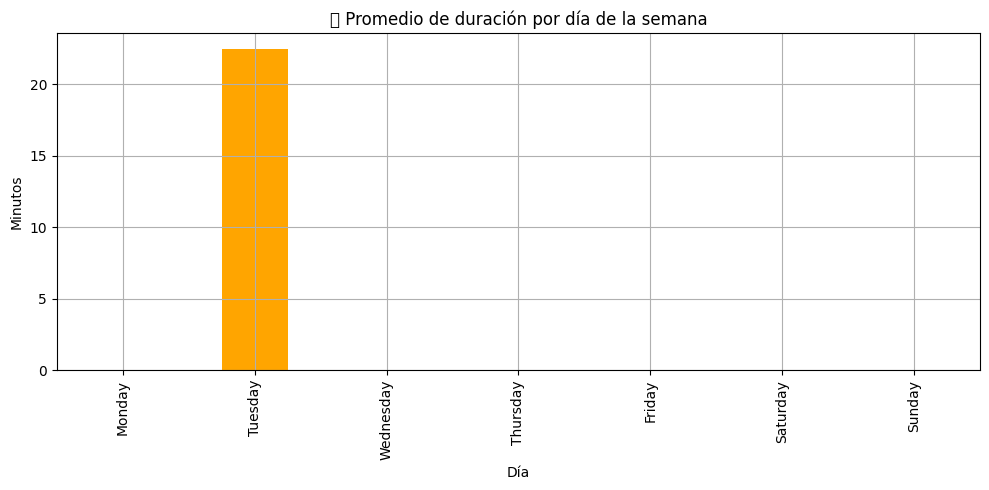

In [9]:
# Gráfico 2: promedio por día de la semana
plt.figure(figsize=(10, 5))
dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.groupby("dia_semana")["minutos"].mean().reindex(dias_orden).plot(kind="bar", color="orange")
plt.title("📅 Promedio de duración por día de la semana")
plt.ylabel("Minutos")
plt.xlabel("Día")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Mostrar picos de tráfico
picos = df[df["minutos"] > 20].copy()
picos["fecha_str"] = picos["fecha"].dt.strftime('%Y-%m-%d %H:%M')
print("🔺 Registros con tráfico alto (>20min):")
display(picos[["fecha_str", "minutos", "estado"]])

🔺 Registros con tráfico alto (>20min):


,fecha_str,minutos,estado
0,2025-07-22 09:58,22.2,🚨 ALTO
1,2025-07-22 09:59,22.2,🚨 ALTO
2,2025-07-22 10:00,22.3,🚨 ALTO
3,2025-07-22 10:00,22.3,🚨 ALTO
4,2025-07-22 10:01,22.2,🚨 ALTO
5,2025-07-22 08:10,22.9,🚨 ALTO
6,2025-07-22 08:27,23.3,🚨 ALTO
